# Explore a Thyra Dataset

This notebook shows how to read Mass Spectrometry Imaging (MSI) data from a
SpatialData store produced by **Thyra**.

For installation and the conversion step that produces such a store, see the
[Tutorial](https://M4i-Imaging-Mass-Spectrometry.github.io/thyra/tutorial/). This notebook picks up from its output.

Topics covered:
- Loading a SpatialData zarr dataset
- Accessing TIC (Total Ion Current) images
- Accessing optical images and MSI-optical overlay
- Accessing the average mass spectrum
- Pixel counts and data representation
- Accessing raw MSI data and pixel coordinates
- Extracting ion images at specific m/z values
- Working with 3D data and z-slices

**Runs with no configuration.** If you have no dataset yet, the setup cell
below generates a small synthetic one and converts it, so every cell can be
executed as-is. To use your own data instead, set the `THYRA_TUTORIAL_ZARR`
environment variable before starting Jupyter.

## Setup

The cell below resolves which dataset to open:

1. `THYRA_TUTORIAL_ZARR`, if that environment variable is set
2. otherwise `example_data/synthetic_brain.zarr`, generating and converting it
   on first run

Generating and converting the synthetic dataset takes a few seconds and needs
no vendor SDK, so it works on Windows, macOS and Linux alike.

Note that `convert_msi()` called without a `resampling_config` keeps the
original m/z axis, whereas the `thyra` command-line tool resamples by default.
Everything below works either way -- only the number of columns in the table
differs.

In [1]:
import warnings

# Silence noisy third-party import warnings so the output below stays
# readable. These come from dask and pkg_resources, not from Thyra.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")

import os
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import spatialdata as sd

# Use your own dataset by setting THYRA_TUTORIAL_ZARR:
#   Windows (cmd)   set THYRA_TUTORIAL_ZARR=D:\data\my_dataset.zarr
#   macOS / Linux   export THYRA_TUTORIAL_ZARR=/data/my_dataset.zarr
# Otherwise a small synthetic dataset is generated and converted here.
DEFAULT_ZARR = Path("example_data/synthetic_brain.zarr")
ZARR_PATH = Path(os.environ.get("THYRA_TUTORIAL_ZARR") or DEFAULT_ZARR)


def build_example_dataset(zarr_path):
    """Generate the synthetic example dataset and convert it."""
    from thyra import convert_msi
    from thyra.tools.make_example_data import generate_example_imzml

    imzml = zarr_path.with_suffix(".imzML")
    if not imzml.exists():
        print("Generating the synthetic example dataset...")
        generate_example_imzml(imzml)

    print("Converting...")
    if not convert_msi(imzml, zarr_path):
        shutil.rmtree(zarr_path, ignore_errors=True)
        raise RuntimeError("Conversion failed -- see the log output above.")


if not ZARR_PATH.exists():
    if ZARR_PATH != DEFAULT_ZARR:
        raise FileNotFoundError(
            f"THYRA_TUTORIAL_ZARR points at a path that does not exist: {ZARR_PATH}"
        )
    build_example_dataset(DEFAULT_ZARR)

sdata = sd.read_zarr(ZARR_PATH)
print(f"Loaded: {ZARR_PATH}")
print("Tables:", list(sdata.tables.keys()))
print("Images:", list(sdata.images.keys()))
print("Shapes:", list(sdata.shapes.keys()))

Generating the synthetic example dataset...


Converting...


Converting spectra:   0%|          | 0/1728 [00:00<?, ?spectrum/s]

Converting spectra:  29%|██▉       | 497/1728 [00:00<00:00, 4518.12spectrum/s]

Converting spectra:  55%|█████▌    | 953/1728 [00:00<00:00, 4533.28spectrum/s]

Converting spectra:  81%|████████▏ | 1407/1728 [00:00<00:00, 4391.85spectrum/s]

Converting spectra: 100%|██████████| 1728/1728 [00:00<00:00, 4272.38spectrum/s]

Loaded: example_data\synthetic_brain.zarr
Tables: ['msi_dataset_z0']
Images: ['msi_dataset_z0_tic']
Shapes: ['msi_dataset_z0_pixels']


## SpatialData Structure Overview

A Thyra-converted dataset contains:

| Element | Key pattern | Description |
|---------|------------|-------------|
| **Table** | `{dataset_id}` | AnnData table with intensity matrix (pixels x m/z), coordinates in `.obs`, m/z axis in `.var`, average spectrum in `.uns` |
| **TIC Image** | `{dataset_id}_tic` | 2D image of total ion current per pixel, shape `(c, y, x)` with `c=1` |
| **Pixel Shapes** | `{dataset_id}_pixels` | GeoDataFrame with pixel geometries |
| **Optical Image** | `{dataset_id}_optical` | Microscopy image (if available) |

For 3D sliced data, keys include a z-index: `{dataset_id}_z{i}`, `{dataset_id}_z{i}_tic`, etc.

## Accessing TIC Images

The TIC image represents the sum of all intensities across the mass spectrum for each pixel.

In [2]:
# Find TIC image key -- match "_tic" suffix to avoid matching "optical"
tic_keys = [key for key in sdata.images.keys() if key.endswith("_tic")]
print("TIC image keys:", tic_keys)

tic_key = tic_keys[0]
tic_image = sdata.images[tic_key]

# Convert to numpy -- the stored shape is (c, y, x) with c=1
# Use np.asarray() for robust access regardless of backend (xarray, dask, zarr)
tic_array = np.asarray(tic_image)[0]  # drop channel dim -> (y, x)

print(f"TIC image shape: {tic_array.shape}")
print(f"Intensity range: {tic_array.min():.2f} -- {tic_array.max():.2f}")

TIC image keys: ['msi_dataset_z0_tic']
TIC image shape: (36, 48)
Intensity range: 16176.91 -- 146471.64


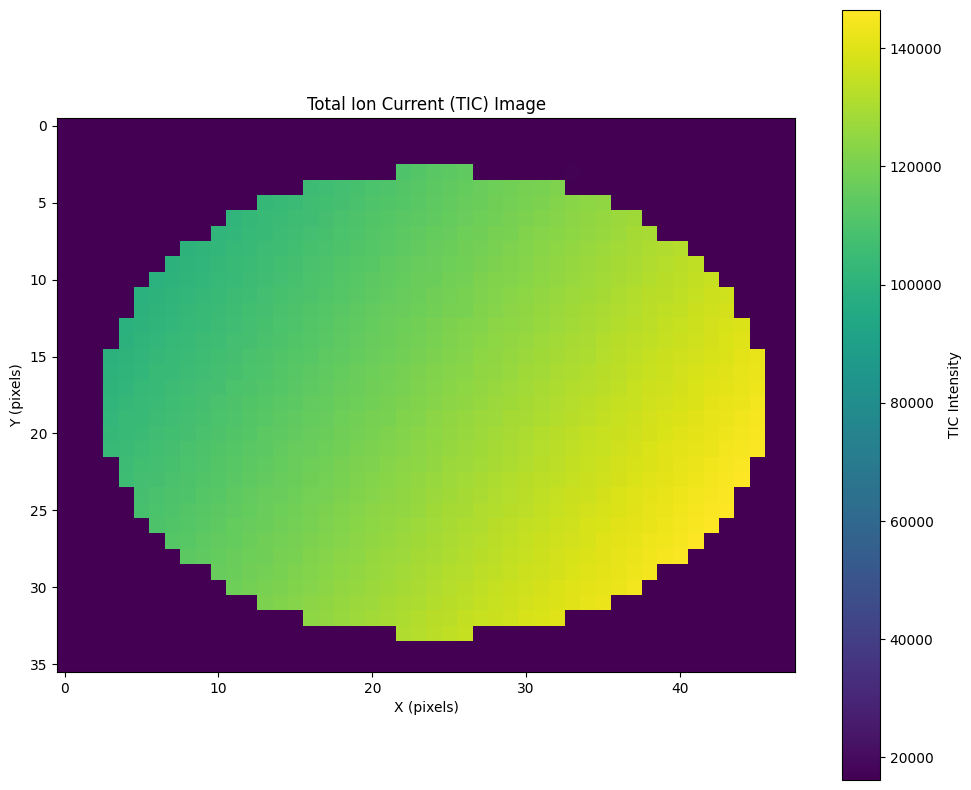

In [3]:
# Visualize the TIC image
plt.figure(figsize=(10, 8))
plt.imshow(tic_array, cmap="viridis")
plt.colorbar(label="TIC Intensity")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.title("Total Ion Current (TIC) Image")
plt.tight_layout()
plt.show()

## Accessing Optical Images

When converted with `include_optical=True`, Thyra stores microscopy images
alongside the MSI data. Keys follow the pattern `{dataset_id}_optical_{suffix}`
where suffix is `highres`, `derived`, or derived from the filename.

Optical images and MSI-to-optical alignment come from vendor metadata, so they
are present for **Bruker** acquisitions and absent for plain imzML input --
including the synthetic example dataset. The next few cells therefore print a
notice instead of a figure unless you are pointing at a Bruker conversion. See
[Tutorial, Part 2](https://M4i-Imaging-Mass-Spectrometry.github.io/thyra/tutorial/#part-2-the-published-example-dataset) for a
dataset that exercises this path.

In [4]:
# Find optical image keys (exclude TIC images)
optical_keys = [key for key in sdata.images.keys() if "optical" in key]
print("Optical image keys:", optical_keys)

if optical_keys:
    # The primary optical image (highres) has an Identity transform --
    # it defines the coordinate system that the TIC affine maps into.
    # Other optical images may have Scale transforms to align with it.
    from spatialdata.transformations import get_transformation, Identity

    primary_key = None
    for key in optical_keys:
        transforms = get_transformation(sdata.images[key], get_all=True)
        for t in transforms.values():
            if isinstance(t, Identity):
                primary_key = key
                break
        if primary_key:
            break

    # Fallback: pick the one with "highres" in the name, or the largest
    if primary_key is None:
        highres = [k for k in optical_keys if "highres" in k]
        primary_key = highres[0] if highres else optical_keys[0]

    print(f"\nPrimary optical image: {primary_key}")
    opt_image = np.asarray(sdata.images[primary_key])  # shape: (c, y, x)
    print(f"Shape: {opt_image.shape} (channels, y, x), dtype: {opt_image.dtype}")

    # Display -- transpose (c, y, x) -> (y, x, c) for RGB
    if opt_image.shape[0] == 3:
        opt_rgb = np.moveaxis(opt_image, 0, -1)  # (y, x, 3)
    elif opt_image.shape[0] == 1:
        opt_rgb = opt_image[0]  # grayscale
    else:
        opt_rgb = np.moveaxis(opt_image[:3], 0, -1)  # take first 3 channels

    plt.figure(figsize=(10, 8))
    plt.imshow(opt_rgb)
    plt.title(f"Optical Image -- {primary_key}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No optical images found (convert with include_optical=True)")

Optical image keys: []
No optical images found (convert with include_optical=True)


### Overlaying MSI Data on Optical Image

The optical image typically shows the full slide (e.g. multiple tissue sections), while the TIC only covers the measured region. Thyra stores an **Affine transform** on the TIC image that maps its raster indices into the optical image's pixel coordinate space. We extract this transform and use it to place the TIC at the correct position on the optical.

In [5]:
from scipy.ndimage import zoom as ndi_zoom
from spatialdata.transformations import get_transformation

if optical_keys:
    opt_h, opt_w = opt_rgb.shape[:2]
    tic_h, tic_w = tic_array.shape

    # Extract the affine transform stored on the TIC image.
    # This is a 3x3 matrix: [[sx, 0, tx], [0, sy, ty], [0, 0, 1]]
    # mapping TIC raster indices (x, y) to optical pixel coordinates.
    tic_element = sdata.images[tic_key]
    transform = get_transformation(tic_element, get_all=True)

    # Pick the dataset-specific or global transform
    t = list(transform.values())[0]
    affine_matrix = np.array(t.to_affine_matrix(input_axes=("x", "y"), output_axes=("x", "y")))
    print(f"TIC affine transform:\n{affine_matrix}")

    sx, sy = affine_matrix[0, 0], affine_matrix[1, 1]
    tx, ty = affine_matrix[0, 2], affine_matrix[1, 2]

    # Compute where the TIC lands on the optical image
    # TIC pixel (0,0) maps to optical pixel (tx, ty)
    # TIC pixel (w,h) maps to optical pixel (tx + w*sx, ty + h*sy)
    opt_x_start = tx - sx / 2  # half-pixel offset (center vs corner)
    opt_y_start = ty - sy / 2
    opt_x_end = opt_x_start + tic_w * sx
    opt_y_end = opt_y_start + tic_h * sy

    print(f"\nTIC region on optical: x=[{opt_x_start:.0f}, {opt_x_end:.0f}], "
          f"y=[{opt_y_start:.0f}, {opt_y_end:.0f}]")
    print(f"Optical size: {opt_w}x{opt_h}, TIC size: {tic_w}x{tic_h}")
    print(f"Scale: {sx:.2f}x, {sy:.2f}x per TIC pixel")

    # Resize TIC to match optical pixel scale
    tic_resized = ndi_zoom(tic_array, (abs(sy), abs(sx)), order=1)

    # Create an optical-sized canvas and place the TIC at the correct position
    tic_on_optical = np.zeros((opt_h, opt_w))
    y0 = int(round(opt_y_start))
    x0 = int(round(opt_x_start))
    # Clip to stay within optical bounds
    src_y0 = max(0, -y0)
    src_x0 = max(0, -x0)
    dst_y0 = max(0, y0)
    dst_x0 = max(0, x0)
    copy_h = min(tic_resized.shape[0] - src_y0, opt_h - dst_y0)
    copy_w = min(tic_resized.shape[1] - src_x0, opt_w - dst_x0)

    if copy_h > 0 and copy_w > 0:
        tic_on_optical[dst_y0:dst_y0 + copy_h, dst_x0:dst_x0 + copy_w] = \
            tic_resized[src_y0:src_y0 + copy_h, src_x0:src_x0 + copy_w]

    # Normalize for overlay
    tic_max = tic_on_optical.max()
    tic_norm = tic_on_optical / tic_max if tic_max > 0 else tic_on_optical

    # Plot: optical, TIC placed, overlay
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(opt_rgb)
    axes[0].set_title("Optical")
    axes[0].axis("off")

    axes[1].imshow(opt_rgb)
    mask = tic_norm > 0.01
    tic_overlay = np.ma.masked_where(~mask, tic_norm)
    axes[1].imshow(tic_overlay, cmap="hot", alpha=0.6, vmin=0, vmax=1)
    axes[1].set_title("Optical + TIC Overlay")
    axes[1].axis("off")

    # Zoomed view of just the TIC region
    pad = 50  # pixels of padding around the TIC region
    axes[2].imshow(opt_rgb)
    axes[2].imshow(tic_overlay, cmap="hot", alpha=0.6, vmin=0, vmax=1)
    axes[2].set_xlim(max(0, x0 - pad), min(opt_w, x0 + tic_resized.shape[1] + pad))
    axes[2].set_ylim(min(opt_h, y0 + tic_resized.shape[0] + pad), max(0, y0 - pad))
    axes[2].set_title("Zoomed Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No optical image available for overlay")

No optical image available for overlay

## Accessing the Average Mass Spectrum

The average spectrum is the mean intensity across all **non-empty** pixels for each m/z value. It is stored in the `.uns` attribute of the main data table.

In [6]:
# Get the main MSI table
table_key = list(sdata.tables.keys())[0]
msi_table = sdata.tables[table_key]
print(f"Table: {table_key}, shape: {msi_table.shape} (pixels x m/z values)")

# Average spectrum from .uns
avg_spectrum = msi_table.uns["average_spectrum"]

# m/z axis from .var
mz_values = msi_table.var["mz"].values

print(f"m/z range: {mz_values.min():.4f} -- {mz_values.max():.4f}")
print(f"Number of m/z bins: {len(mz_values)}")

Table: msi_dataset_z0, shape: (1728, 4000) (pixels x m/z values)
m/z range: 250.0000 -- 1200.0000
Number of m/z bins: 4000


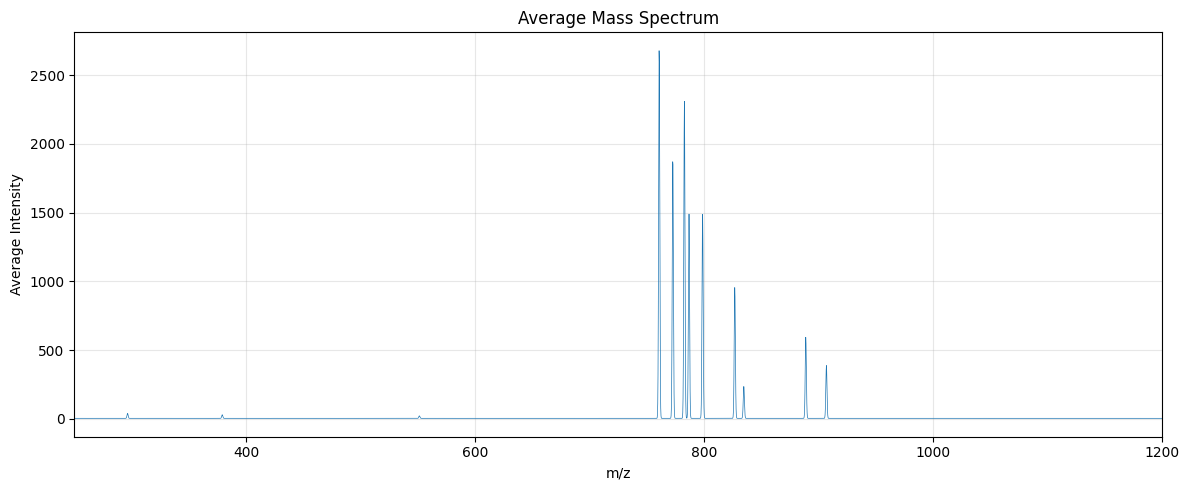

In [7]:
# Plot the average mass spectrum
plt.figure(figsize=(12, 5))
plt.plot(mz_values, avg_spectrum, linewidth=0.5)
plt.xlabel("m/z")
plt.ylabel("Average Intensity")
plt.title("Average Mass Spectrum")
plt.xlim(mz_values.min(), mz_values.max())
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Pixel Count and Data Representation

MSI data is stored in a rectangular grid, but not all grid positions contain measurements. The TIC image makes it easy to distinguish data pixels from empty ones.

In [8]:
# Count pixels
total_pixels = tic_array.size
non_empty_pixels = np.count_nonzero(tic_array)

print(f"Total pixels in grid:          {total_pixels:,}")
print(f"Non-empty pixels (with data):  {non_empty_pixels:,}")
print(f"Coverage:                      {non_empty_pixels / total_pixels * 100:.1f}%")

Total pixels in grid:          1,728
Non-empty pixels (with data):  1,728
Coverage:                      100.0%


## Accessing Raw MSI Data

The intensity matrix is stored as a sparse matrix in the AnnData table. Each row is one pixel, each column is one m/z bin.

In [9]:
X = msi_table.X  # sparse matrix (pixels x m/z)
print(f"Data matrix type: {type(X).__name__}")
print(f"Shape: {X.shape} (pixels x m/z values)")

if sparse.issparse(X):
    nnz = X.nnz
    total = X.shape[0] * X.shape[1]
    print(f"Non-zero entries: {nnz:,} / {total:,} ({nnz / total * 100:.2f}%)")

Data matrix type: csc_matrix
Shape: (1728, 4000) (pixels x m/z values)
Non-zero entries: 6,885,838 / 6,912,000 (99.62%)


### Pixel Coordinates

In [10]:
# Coordinates are stored in .obs
print("Available obs columns:", list(msi_table.obs.columns))

# Access spatial coordinates
x_coords = msi_table.obs["x"].values.astype(float)
y_coords = msi_table.obs["y"].values.astype(float)

print(f"X range: {x_coords.min():.1f} -- {x_coords.max():.1f}")
print(f"Y range: {y_coords.min():.1f} -- {y_coords.max():.1f}")
print(f"Number of pixels with coordinates: {len(x_coords):,}")

Available obs columns: ['y', 'x', 'region', 'spatial_x', 'spatial_y', 'region_number', 'instance_key']
X range: 0.0 -- 47.0
Y range: 0.0 -- 35.0
Number of pixels with coordinates: 1,728


### Extracting Individual Spectra

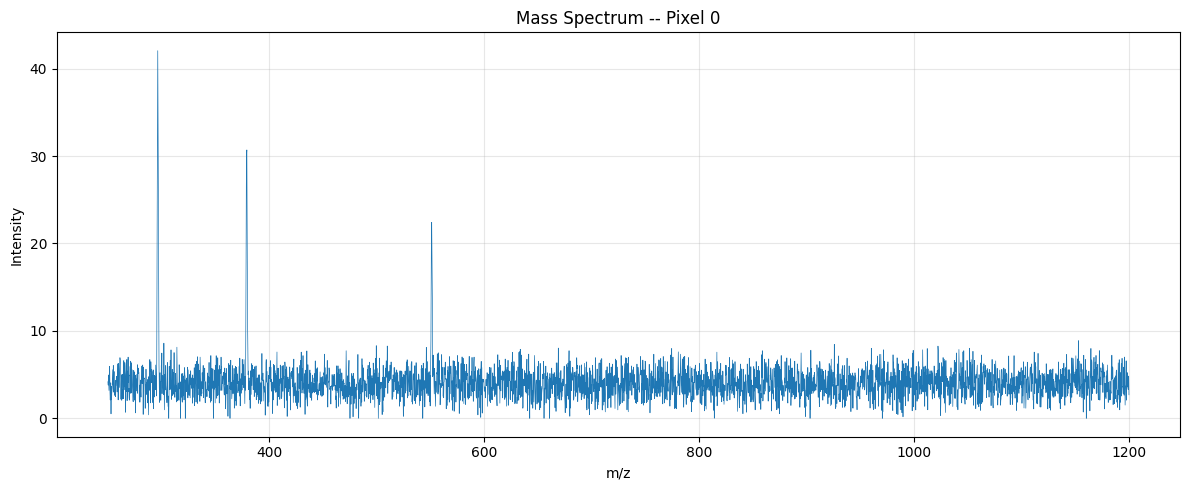

In [11]:
# Get spectrum for a specific pixel
pixel_idx = 0
if sparse.issparse(X):
    pixel_spectrum = X[pixel_idx].toarray().flatten()
else:
    pixel_spectrum = np.asarray(X[pixel_idx]).flatten()

plt.figure(figsize=(12, 5))
plt.plot(mz_values, pixel_spectrum, linewidth=0.5)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title(f"Mass Spectrum -- Pixel {pixel_idx}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Extracting Ion Images

To visualise the spatial distribution of a specific m/z value, extract the
corresponding intensities from the matrix and reshape them into image
coordinates.

The cell below starts from the most intense peak in the average spectrum, which
is guaranteed to be a populated bin. To map an *arbitrary* target m/z, integrate
over a tolerance window instead -- see
[Searching for a Specific m/z Value](#searching-for-a-specific-mz-value) below.

In [12]:
# Find the highest peak in the average spectrum
peak_idx = np.argmax(avg_spectrum)
target_mz = mz_values[peak_idx]
print(f"Highest average peak: m/z {target_mz:.4f}")

# Extract intensities for this m/z across all pixels
if sparse.issparse(X):
    ion_intensities = np.asarray(X[:, peak_idx].toarray()).flatten()
else:
    ion_intensities = np.asarray(X[:, peak_idx]).flatten()

print(f"Intensity range: {ion_intensities.min():.2f} -- {ion_intensities.max():.2f}")

Highest average peak: m/z 760.5151
Intensity range: 0.00 -- 5468.85


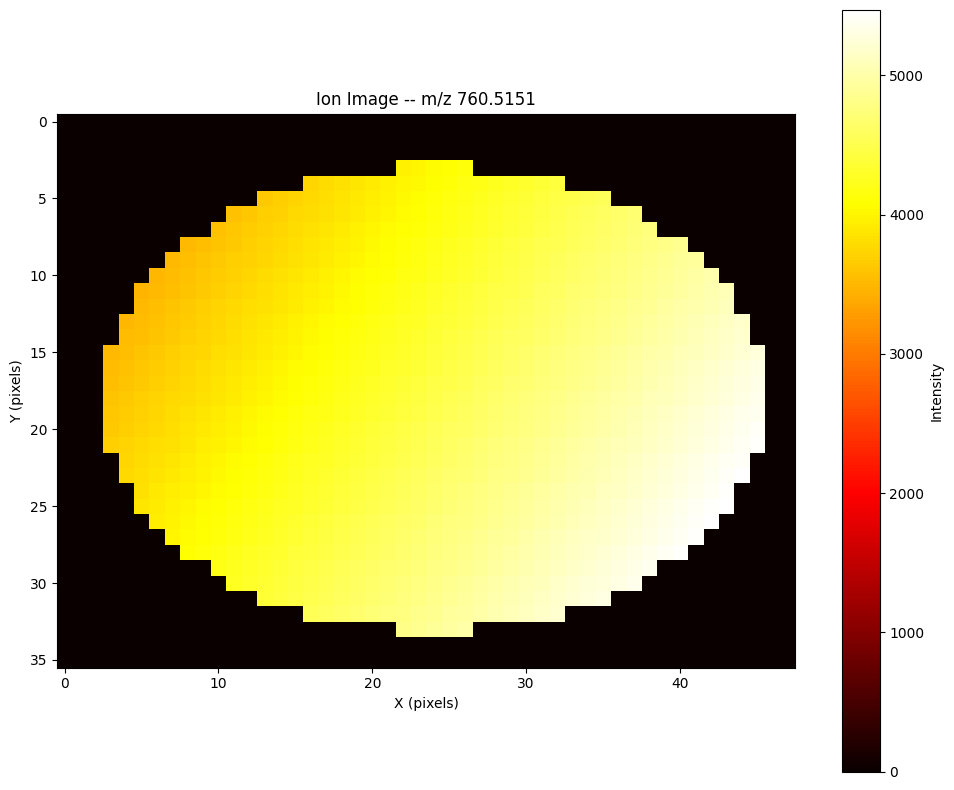

In [13]:
# Reconstruct the ion image from pixel coordinates
x_unique = np.sort(np.unique(x_coords))
y_unique = np.sort(np.unique(y_coords))

ion_image = np.zeros((len(y_unique), len(x_unique)))

# Map coordinates to grid indices
x_step = x_unique[1] - x_unique[0] if len(x_unique) > 1 else 1.0
y_step = y_unique[1] - y_unique[0] if len(y_unique) > 1 else 1.0
x_indices = np.round((x_coords - x_unique.min()) / x_step).astype(int)
y_indices = np.round((y_coords - y_unique.min()) / y_step).astype(int)

for xi, yi, val in zip(x_indices, y_indices, ion_intensities):
    if 0 <= xi < len(x_unique) and 0 <= yi < len(y_unique):
        ion_image[yi, xi] = val

plt.figure(figsize=(10, 8))
plt.imshow(ion_image, cmap="hot")
plt.colorbar(label="Intensity")
plt.title(f"Ion Image -- m/z {target_mz:.4f}")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.tight_layout()
plt.show()

### Searching for a Specific m/z Value

In [14]:
# Look up a specific m/z by integrating over a tolerance window.
#
# Do NOT use a single nearest bin (np.abs(mz_values - target).argmin()):
# on a resampled axis most bins are empty by construction, so the nearest
# bin to an arbitrary target is very often zero even when the peak is
# present a few bins away.
target_mz = 760.5  # change this to your m/z of interest
mz_tolerance = 0.25

lo, hi = np.searchsorted(mz_values, [target_mz - mz_tolerance, target_mz + mz_tolerance])

if hi > lo:
    window_values = np.asarray(X[:, lo:hi].sum(axis=1)).ravel()
    populated = np.count_nonzero(np.asarray(avg_spectrum)[lo:hi])
    print(f"Window m/z {target_mz} +/- {mz_tolerance}: {hi - lo} bins, "
          f"{populated} of them populated")
    print(f"Summed intensity range: {window_values.min():.2f} -- {window_values.max():.2f}")
else:
    print(f"No m/z bins within {mz_tolerance} of {target_mz} "
          f"(axis covers {mz_values.min():.2f} -- {mz_values.max():.2f})")

Window m/z 760.5 +/- 0.25: 2 bins, 2 of them populated
Summed intensity range: 1.78 -- 9976.33


## Recalculating TIC and Average Spectrum

You can recompute TIC and average spectrum directly from the intensity matrix to verify the stored values.

In [15]:
# Recalculate TIC per pixel
if sparse.issparse(X):
    recalc_tic = np.asarray(X.sum(axis=1)).flatten()
else:
    recalc_tic = X.sum(axis=1)

print(f"Recalculated TIC range: {recalc_tic.min():.2f} -- {recalc_tic.max():.2f}")

Recalculated TIC range: 16176.91 -- 146471.63


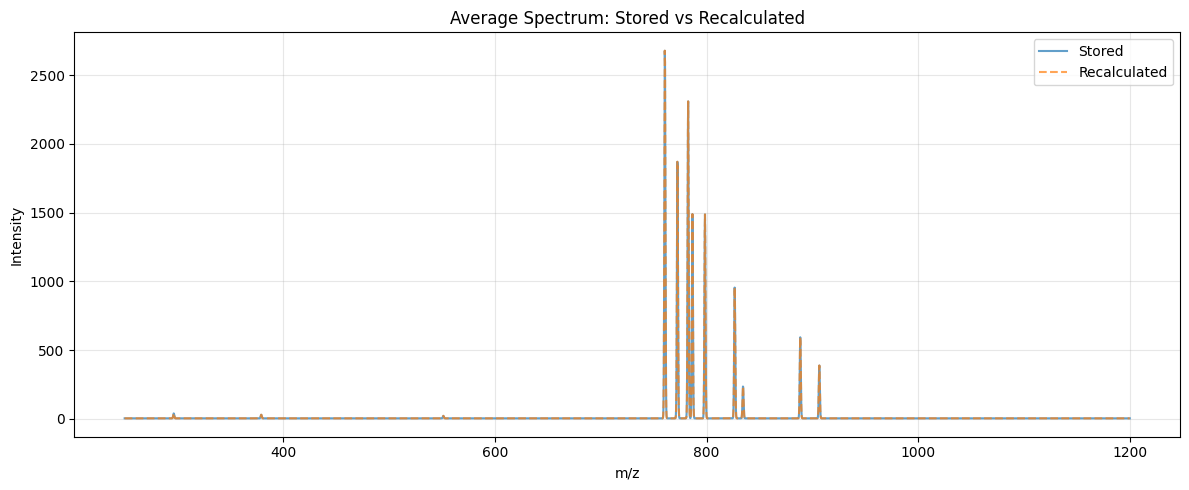

In [16]:
# Recalculate average spectrum (non-empty pixels only)
if sparse.issparse(X):
    nonzero_rows = np.diff(X.tocsr().indptr) > 0
    X_nonzero = X[nonzero_rows]
    recalc_avg = np.asarray(X_nonzero.mean(axis=0)).flatten()
else:
    nonzero_rows = np.any(X > 0, axis=1)
    recalc_avg = X[nonzero_rows].mean(axis=0)

# Compare with stored average
plt.figure(figsize=(12, 5))
plt.plot(mz_values, avg_spectrum, label="Stored", alpha=0.7)
plt.plot(mz_values, recalc_avg, label="Recalculated", alpha=0.7, linestyle="--")
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.title("Average Spectrum: Stored vs Recalculated")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Working with 3D Data and Z-Slices

For 3D datasets, Thyra stores each z-slice as a separate table and TIC image with `_z{i}` suffixes.

In [17]:
# Every Thyra table carries a _z{i} suffix, so the presence of "_z" alone
# does not mean the dataset is 3D -- a plain 2D acquisition is just _z0.
# A genuine 3D dataset has more than one slice.
slice_table_keys = sorted(key for key in sdata.tables.keys() if "_z" in key)
slice_tic_keys = sorted(
    key for key in sdata.images.keys() if "_z" in key and key.endswith("_tic")
)

print(f"Slices found: {len(slice_table_keys)} -> {slice_table_keys}")
print()

if len(slice_table_keys) > 1:
    print(f"3D dataset with {len(slice_table_keys)} z-slices")
    print(f"  TIC keys: {slice_tic_keys}")

    # Access a single z-slice
    z_table = sdata.tables[slice_table_keys[0]]
    print(f"  Slice 0 shape: {z_table.shape}")

    if slice_tic_keys:
        z_tic = np.asarray(sdata.images[slice_tic_keys[0]])[0]
        plt.figure(figsize=(8, 6))
        plt.imshow(z_tic, cmap="viridis")
        plt.colorbar(label="TIC")
        plt.title(f"TIC -- {slice_tic_keys[0]}")
        plt.tight_layout()
        plt.show()
else:
    print("Single 2D dataset (one z-slice).")
    print("Convert with --handle-3d to combine a volume into one table instead.")

Slices found: 1 -> ['msi_dataset_z0']

Single 2D dataset (one z-slice).
Convert with --handle-3d to combine a volume into one table instead.


## Pixel Size and Dataset Metadata

Pixel size and conversion metadata are stored in `sdata.attrs` (SpatialData-level attributes). Additional metadata (instrument info, acquisition params, etc.) is in the table's `.uns`.

In [18]:
# Pixel size from SpatialData attrs
if "pixel_size_x_um" in sdata.attrs:
    print(f"Pixel size X: {sdata.attrs['pixel_size_x_um']} um")
    print(f"Pixel size Y: {sdata.attrs['pixel_size_y_um']} um")
else:
    print("Pixel size not found in sdata.attrs")

# Dataset info
if "msi_dataset_info" in sdata.attrs:
    info = sdata.attrs["msi_dataset_info"]
    print(f"\nDataset ID: {info.get('dataset_id')}")
    print(f"Dimensions (x, y, z): {info.get('dimensions_xyz')}")
    print(f"Non-empty pixels: {info.get('non_empty_pixels'):,}")
    print(f"Total grid pixels: {info.get('total_grid_pixels'):,}")

# Table-level metadata
print(f"\nTable .uns keys: {list(msi_table.uns.keys())}")

Pixel size X: 25.0 um
Pixel size Y: 25.0 um

Dataset ID: msi_dataset
Dimensions (x, y, z): [48, 36, 1]
Non-empty pixels: 1,728
Total grid pixels: 1,728

Table .uns keys: ['average_spectrum', 'format_specific', 'essential_metadata', 'raw_metadata', 'regions', 'spatialdata_attrs']


## Implementation Notes

**Average spectrum** is calculated using only non-empty pixels (those with at least one non-zero intensity). This prevents artificial dilution from empty grid positions.

**TIC image orientation** follows standard imaging convention: first axis is Y (rows, top to bottom), second is X (columns, left to right).

**Sparse storage**: MSI data is highly sparse. Keep data in sparse format when possible and avoid `.toarray()` on the full matrix for large datasets.

**Loading**: Use `spatialdata.read_zarr()` to load datasets. This returns a `SpatialData` object with lazy-loaded elements.